### 1 a) Simulation of the Healthy Aging process
The 2-element Windkessel model ($WK_2$) represents the systemic circulation through two parameters:
* **Arterial Compliance ($C_A$)**: Represents the elasticity of the main arteries.
* **Peripheral Resistance ($R_P$)**: Represents the opposition to blood flow in the smallest vessels (arterioles).

**Physiology of aging:** Over the years, the arterial walls become stiffer (less distensibility), which translates into a **decrease in compliance ($C_A$)**. As a compensatory mechanism and due to vascular changes, there is usually an **increase in peripheral resistance ($R_P$)**.

Next, we will reduce $C_A$ and increase $R_P$ with respect to the baseline values of the healthy patient to observe how the pulse pressure (difference between systolic and diastolic pressure) widens.

In [ ]:
# -------------------------------------------------------------------------
# GENERAL USE MODULES AND FLOW FUNCTION
# -------------------------------------------------------------------------
import numpy as np
import matplotlib.pyplot as plt
import scipy as sp
import pandas as pd

def Q_Sim(Qmax, T, t):
    """
    ===============================================================================
    Flow_Sim: Generation of a FLOW signal (Half-sine) similar to human [ml/s]
    Input parameters:
      -Qmax: Maximum Flow
      -T: Period duration
      -t: Evaluation range
    ==============================================================================
    """
    Escala_ml = 1e5 * (Qmax / 8.8) # Adjustment to (500 ml/s)
    Q = Escala_ml * ((7.9853e-06 + 2.6617e-05*np.sin(2*np.pi*t/T+0.29498) +
                      2.3616e-05*np.sin(4*np.pi*t/T-1.1403) - 1.9016e-05*np.sin(6*np.pi*t/T+0.40435) -
                      8.5899e-06*np.sin(8*np.pi*t/T-1.1892) - 2.436e-06*np.sin(10*np.pi*t/T-1.4918) +
                      1.4905e-06*np.sin(12*np.pi*t/T+1.0536) + 1.3581e-06*np.sin(14*np.pi*t/T-0.47666) -
                      6.3031e-07*np.sin(16*np.pi*t/T+0.93768) - 4.5335e-07*np.sin(18*np.pi*t/T-0.79472) -
                      4.5184e-07*np.sin(20*np.pi*t/T-1.4095) - 5.6583e-07*np.sin(22*np.pi*t/T-1.3629) +
                      4.9522e-07*np.sin(24*np.pi*t/T+0.52495) + 1.3049e-07*np.sin(26*np.pi*t/T-0.97261) -
                      4.1072e-08*np.sin(28*np.pi*t/T-0.15685) - 2.4182e-07*np.sin(30*np.pi*t/T-1.4052) -
                      6.6217e-08*np.sin(32*np.pi*t/T-1.3785) - 1.5511e-07*np.sin(34*np.pi*t/T-1.2927) +
                      2.2149e-07*np.sin(36*np.pi*t/T+0.68178) + 6.7621e-08*np.sin(38*np.pi*t/T-0.98825) +
                      1.0973e-07*np.sin(40*np.pi*t/T+1.4327) - 2.5559e-08*np.sin(42*np.pi*t/T-1.2372) -
                      3.5079e-08*np.sin(44*np.pi*t/T+0.2328)))
    return Q

In [ ]:
# -------------------------------------------------------------------------
# NUMERICAL RESOLUTION OF THE WK2 MODEL
# -------------------------------------------------------------------------

def resolver_wk2_euler(Q, t, Ca, Rp):
    """
    Solves the 2-element Windkessel model (WK2) using Euler's method.
    """
    dt = t[1] - t[0]              # Integration step (sampling period)
    P = np.zeros(len(t))          # Vector initialized to zeros for Pressure

    # Initial condition: assuming a starting diastolic pressure (e.g., 80 mmHg)
    P[0] = 80.0

    # Euler's loop to solve step by step
    for i in range(1, len(t)):
        # Pressure derivative: dP/dt = Q/Ca - P/(Rp*Ca)
        dP_dt = (Q[i-1] / Ca) - (P[i-1] / (Rp * Ca))
        # Update
        P[i] = P[i-1] + (dP_dt * dt)

    return P

### Numerical Resolution and Visualization (Signal Processing)
Having our flow vector $Q(t)$ acting as the system's excitation and our sampling frequency established, we now solve the **Ordinary Differential Equation (ODE)** of the $WK_2$:

$\frac{dP_{AO}}{dt} = \frac{Q(t)}{C_A} - \frac{P_{AO}(t)}{R_P \cdot C_A}$

Since in DSP we work with discrete signals, we can integrate this equation step by step using Euler's method. Then, we plot the result to analyze the morphology of the new aortic pressure wave.

Baseline Parameters -> Ca: 1.10 | Rp: 0.90
Aging Parameters -> Ca: 0.66 | Rp: 1.17


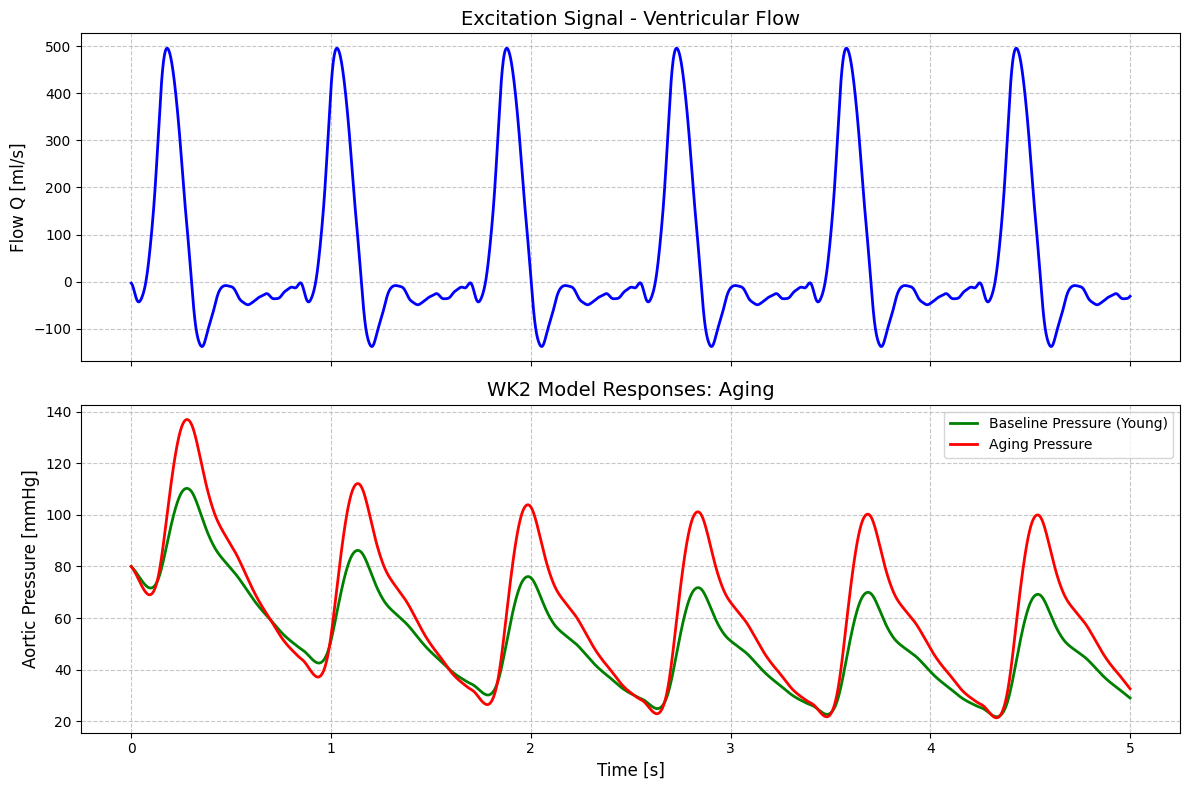

In [ ]:
# -------------------------------------------------------------------------
# SIMULATION 1a: HEALTHY AGING AND VISUALIZATION
# -------------------------------------------------------------------------

# 1. Temporal and flow parameters
Ts = 0.001                  # Sampling period (seconds)
t = np.arange(0, 5, Ts)     # Evaluation range (5 seconds to properly appreciate the heartbeats)
T0 = 0.85                   # Duration of one heartbeat
Qmax = 500                  # Maximum Flow [ml/s]

# Generation of the excitation vector (Flow)
Q_entrada = Q_Sim(Qmax, T0, t)

# 2. Baseline Physiological Parameters (Typical reference values)
Ca_basal = 1.1  # ml/mmHg
Rp_basal = 0.9  # mmHg·s/ml

# 3. Physiological alteration due to Healthy Aging:
# - Arterial distensibility drops (lower Ca)
# - Peripheral resistance increases (higher Rp)
Ca_env = Ca_basal * 0.60
Rp_env = Rp_basal * 1.30

print(f"Baseline Parameters -> Ca: {Ca_basal:.2f} | Rp: {Rp_basal:.2f}")
print(f"Aging Parameters -> Ca: {Ca_env:.2f} | Rp: {Rp_env:.2f}")

# 4. Model resolution for both cases (for visual comparison)
P_basal = resolver_wk2_euler(Q_entrada, t, Ca_basal, Rp_basal)
P_env = resolver_wk2_euler(Q_entrada, t, Ca_env, Rp_env)

# 5. Plotting the results
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

# Upper Plot: Excitation Signal (Flow)
ax1.plot(t, Q_entrada, 'b', linewidth=2)
ax1.set_ylabel('Flow Q [ml/s]', fontsize=12)
ax1.set_title('Excitation Signal - Ventricular Flow', fontsize=14)
ax1.grid(True, linestyle='--', alpha=0.7)

# Lower Plot: Response Signals (Pressures)
ax2.plot(t, P_basal, 'g', linewidth=2, label='Baseline Pressure (Young)')
ax2.plot(t, P_env, 'r', linewidth=2, label='Aging Pressure')
ax2.set_xlabel('Time [s]', fontsize=12)
ax2.set_ylabel('Aortic Pressure [mmHg]', fontsize=12)
ax2.set_title('WK2 Model Responses: Aging', fontsize=14)
ax2.grid(True, linestyle='--', alpha=0.7)
ax2.legend(loc='upper right')

plt.tight_layout()
plt.show()

### Conclusion of the analysis (1 a)

Based on the simulated results for healthy aging, we can observe that the loss of arterial compliance (reduction of $C_A$) generates a significant widening of the pulse pressure. As the arteries become stiffer, they lose their ability to dampen the peak of the flow wave ejected by the left ventricle (acting as a smaller capacitor, filtering the signal less), which causes a higher systolic pressure. On the other hand, the compensatory increase in peripheral resistance ($R_P$) attempts to maintain the mean pressure, but the overall morphology of the aortic pressure wave presents a greater amplitude (ripple) compared to that of a healthy young patient.